# Data Science Topics and Code Examples

## 1. Probability
Probability is a way of quantifying the uncertainty associated with events chosen from a universe of events. It is essential for data science to understand the laws and mathematics of probability.

In [ ]:
# No specific code example given for probability

## 2. Dependence and Independence
Two events E and F are dependent if knowing whether E happens gives us information about whether F happens. Otherwise, they are independent.

For instance, if we flip a fair coin twice, knowing whether the first flip is Heads gives us no information about whether the second flip is Heads. These events are independent. On the other hand, knowing whether the first flip is Heads gives us information about whether both flips are Tails.

In [28]:
# Example to illustrate dependence and independence
import random
def flip_coin():
    return random.choice(['Heads', 'Tails'])

first_flip = flip_coin()
second_flip = flip_coin()
print(f"First flip: {first_flip}")
print(f"Second flip: {second_flip}")

both_flips = (first_flip == 'Heads') and (second_flip == 'Heads')
print(f"Both flips are Heads: {both_flips}")

First flip: Heads
Second flip: Tails
Both flips are Heads: False


## 3. Conditional Probability
The probability of an event E happening given that another event F has occurred is called conditional probability. This can be defined as:

P(E | F) = P(E and F) / P(F)

In [5]:
# No specific code example given for conditional probability

## 4. Bayes’s Theorem
Bayes’s Theorem is a way of reversing conditional probabilities. It allows us to find the probability of an event based on prior knowledge of conditions related to the event.
$$P(E \mid F) = \frac{P(F \mid E) \cdot P(E)}{P(F)}$$

In [29]:
# Example of Bayes's Theorem in a medical test scenario
def bayes_theorem(p_disease, p_positive_given_disease, p_positive):
    return (p_positive_given_disease * p_disease) / p_positive

# Example values
p_disease = 0.0001
p_positive_given_disease = 0.99
p_positive_given_no_disease = 0.01
p_no_disease = 1 - p_disease

# Total probability of a positive test result
p_positive = (p_positive_given_disease * p_disease) + (p_positive_given_no_disease * p_no_disease)

# Probability of having the disease given a positive test result
p_disease_given_positive = bayes_theorem(p_disease, p_positive_given_disease, p_positive)
print(f"Probability of having the disease given a positive test result: {p_disease_given_positive}")

Probability of having the disease given a positive test result: 0.00980392156862745


## 5. Random Variables
A random variable is a variable whose possible values have an associated probability distribution. For example, a simple random variable equals 1 if a coin flip turns up heads and 0 if the flip turns up tails.

In [30]:
# Example of a simple random variable
def random_coin_flip():
    return 1 if random.random() < 0.5 else 0

flips = [random_coin_flip() for _ in range(10)]
print(f"Coin flips: {flips}")

Coin flips: [1, 0, 1, 0, 1, 0, 1, 1, 1, 0]


## 6. Continuous Distributions
Continuous distributions model distributions across a continuum of outcomes, represented by a probability density function (pdf). For example, the uniform distribution puts equal weight on all numbers between 0 and 1.

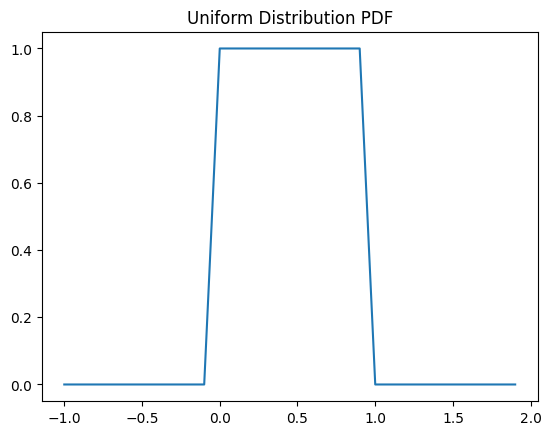

In [11]:
# Example of uniform distribution
import matplotlib.pyplot as plt

def uniform_pdf(x):
    return 1 if 0 <= x < 1 else 0

xs = [x / 10.0 for x in range(-10, 20)]
ys = [uniform_pdf(x) for x in xs]
plt.plot(xs, ys, '-')
plt.title("Uniform Distribution PDF")
plt.show()

## 7. The Normal Distribution
The normal distribution, or bell curve, is determined by two parameters: its mean (μ) and its standard deviation (σ). It has the probability density function (pdf):
```python
def normal_pdf(x, mu=0, sigma=1):
    sqrt_two_pi = math.sqrt(2 * math.pi)
    return (math.exp(-(x-mu) ** 2 / 2 / sigma ** 2) / (sqrt_two_pi * sigma))
```

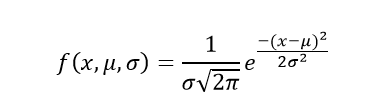

x is the variable
μ is the mean
σ is the standard deviation

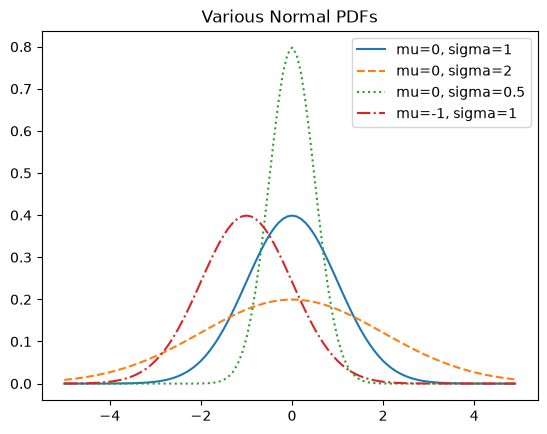

In [4]:
# Example of normal distribution pdf
import math
import matplotlib.pyplot as plt

def normal_pdf(x, mu=0, sigma=1):
    sqrt_two_pi = math.sqrt(2 * math.pi)
    return (math.exp(-(x-mu) ** 2 / 2 / sigma ** 2) / (sqrt_two_pi * sigma))

xs = [x / 10.0 for x in range(-50, 50)]
plt.plot(xs, [normal_pdf(x, sigma=1) for x in xs], '-', label='mu=0, sigma=1')
plt.plot(xs, [normal_pdf(x, sigma=2) for x in xs], '--', label='mu=0, sigma=2')
plt.plot(xs, [normal_pdf(x, sigma=0.5) for x in xs], ':', label='mu=0, sigma=0.5')
plt.plot(xs, [normal_pdf(x, mu=-1) for x in xs], '-.', label='mu=-1, sigma=1')
plt.legend()
plt.title("Various Normal PDFs")
plt.show()

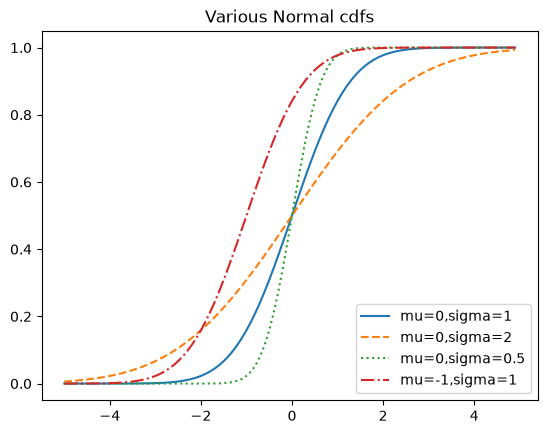

In [16]:
def normal_cdf(x: float, mu: float = 0, sigma: float = 1) -> float:
    return (1 + math.erf((x - mu) / math.sqrt(2) / sigma)) / 2

xs = [x / 10.0 for x in range(-50, 50)]
plt.plot(xs,[normal_cdf(x,sigma=1) for x in xs],'-',label='mu=0,sigma=1')
plt.plot(xs,[normal_cdf(x,sigma=2) for x in xs],'--',label='mu=0,sigma=2')
plt.plot(xs,[normal_cdf(x,sigma=0.5) for x in xs],':',label='mu=0,sigma=0.5')
plt.plot(xs,[normal_cdf(x,mu=-1) for x in xs],'-.',label='mu=-1,sigma=1')
plt.legend(loc=4) # bottom right
plt.title("Various Normal cdfs")
plt.show()

## A Probability Density Function (PDF) measures the likelihood of a continuous random variable taking on an exact value. A Cumulative Distribution Function (CDF) measures the probability that a random variable will take a value less than or equal to a specific value

## 8. The Central Limit Theorem
The central limit theorem states that the distribution of the sample mean approximates a normal distribution as the sample size becomes large.

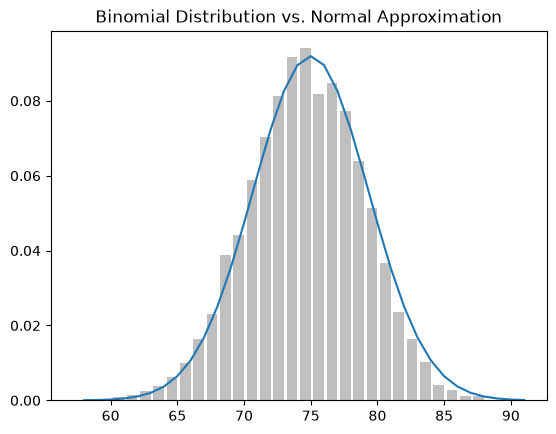

In [8]:
# Example illustrating the central limit theorem with binomial distribution
import random
from collections import Counter
# p is probability of Success
def bernoulli_trial(probability):  #: Simulates a single coin flip.
    return 1 if random.random() < probability else 0

def binomial(n, probability):  #Simulates flipping that biased coin $n$ times and sums the results.
    return sum(bernoulli_trial(probability) for _ in range(n))

def make_hist(probability, n, num_points):
    data = [binomial(n, probability) for _ in range(num_points)]
    histogram = Counter(data)
    plt.bar([x - 0.4 for x in histogram.keys()],
            [v / num_points for v in histogram.values()],
            0.8,
            color='0.75')
    mu = probability * n
    sigma = math.sqrt(n * probability * (1 - probability))
    xs = range(min(data), max(data) + 1)
    ys = [normal_cdf(i + 0.5, mu, sigma) - normal_cdf(i - 0.5, mu, sigma) for i in xs]
    plt.plot(xs, ys)
    plt.title("Binomial Distribution vs. Normal Approximation")
    plt.show()

make_hist(0.75, 100, 10000)

## 9. Hypothesis and Inference
Hypothesis testing involves forming and testing hypotheses about data. It includes statistical hypothesis testing and Bayesian inference.

In [ ]:
# No specific code example given for hypothesis and inference

# 10. Statistical Hypothesis Testing
# Statistical hypothesis testing involves testing whether a certain hypothesis is likely to be true, typically using null and alternative hypotheses.

In [10]:
# Example of hypothesis testing with coin flips
def normal_approximation_to_binomial(n, p):
    mu = p * n
    sigma = math.sqrt(p * (1 - p) * n)
    return mu, sigma

def normal_probability_below(x, mu=0, sigma=1):
    return normal_cdf(x, mu, sigma)

def normal_probability_above(x, mu=0, sigma=1):
    return 1 - normal_cdf(x, mu, sigma)

def normal_probability_between(lo, hi, mu=0, sigma=1):
    return normal_cdf(hi, mu, sigma) - normal_cdf(lo, mu, sigma)

def normal_probability_outside(lo, hi, mu=0, sigma=1):
    return 1 - normal_probability_between(lo, hi, mu, sigma)

def normal_upper_bound(probability: float,
                       mu: float = 0,
                       sigma: float = 1) -> float:
    """Returns the z for which P(Z <= z) = probability"""
    return inverse_normal_cdf(probability, mu, sigma)

def normal_lower_bound(probability: float,
                       mu: float = 0,
                       sigma: float = 1) -> float:
    """Returns the z for which P(Z >= z) = probability"""
    return inverse_normal_cdf(1 - probability, mu, sigma)

def normal_two_sided_bounds(probability, mu=0, sigma=1):
    tail_probability = (1 - probability) / 2
    upper_bound = normal_lower_bound(tail_probability, mu, sigma)
    lower_bound = normal_upper_bound(tail_probability, mu, sigma)
    return lower_bound, upper_bound
def inverse_normal_cdf(p: float,
                       mu: float = 0,
                       sigma: float = 1,
                       tolerance: float = 0.00001) -> float:
    """Find approximate inverse using binary search"""

    # if not standard, compute standard and rescale
    if mu != 0 or sigma != 1:
        return mu + sigma * inverse_normal_cdf(p, tolerance=tolerance)

    low_z = -10.0                      # normal_cdf(-10) is (very close to) 0
    hi_z  =  10.0                      # normal_cdf(10)  is (very close to) 1
    while hi_z - low_z > tolerance:
        mid_z = (low_z + hi_z) / 2     # Consider the midpoint
        mid_p = normal_cdf(mid_z)      # and the cdf's value there
        if mid_p < p:
            low_z = mid_z              # Midpoint too low, search above it
        else:
            hi_z = mid_z               # Midpoint too high, search below it

    return mid_z

# Parameters for a fair coin
mu_0, sigma_0 = normal_approximation_to_binomial(1000, 0.5)

# 95% bounds
lo, hi = normal_two_sided_bounds(0.95, mu_0, sigma_0)
print(f"95% bounds: {lo}, {hi}")

# Test for a biased coin
mu_1, sigma_1 = normal_approximation_to_binomial(1000, 0.55)
type_2_probability = normal_probability_between(lo, hi, mu_1, sigma_1)
power = 1 - type_2_probability
print(f"Power of the test: {power}")

95% bounds: 469.01026640487555, 530.9897335951244
Power of the test: 0.8865480012953671


## 11. Confidence Intervals
Confidence intervals provide a range of values that likely contain the true parameter value, expressing the uncertainty of estimates.

In [12]:
# Example of confidence interval calculation
p_hat = 525 / 1000   # Voter Turnout
mu = p_hat
sigma = math.sqrt(p_hat * (1 - p_hat) / 1000) # Standard Error
interval = normal_two_sided_bounds(0.95, mu, sigma)
print(f"95% confidence interval: {interval}") ## Lower Bound and Upper bound from CDF meaning they support this between 49 to 55 percent

95% confidence interval: (0.4940490278129096, 0.5559509721870904)


## 12. P-hacking
P-hacking is the practice of manipulating data to achieve significant p-values, leading to erroneous rejection of null hypotheses.

In [17]:
# Example illustrating P-hacking
def run_experiment():
    return [random.random() < 0.5 for _ in range(1000)]

def reject_fairness(experiment):
    num_heads = sum(experiment)
    return num_heads < 469 or num_heads > 531 

random.seed(0)
experiments = [run_experiment() for _ in range(1000)]
num_rejections = len([experiment for experiment in experiments if reject_fairness(experiment)])
print(f"Number of rejections: {num_rejections}")

Number of rejections: 46


### The logic: If you flip a coin 1,000 times and get fewer than 469 heads or more than 531 heads, there is less than a 5% chance that the coin is fair. Normally, a scientist would look at this result, see a p-value $< 0.05$, and publish a paper declaring: "We found a biased coin!"

## The Lesson:If you test 1,000 different variables (or run 1,000 variations of an A/B test) looking for a pattern, a 5% false-positive rate means you will automatically find about 50 false positives ($1000 \times 0.05$) purely by luck.If a researcher runs 1,000 tests, ignores the 954 times nothing happened, and only publishes the 46 times they got a "significant" result, that is P-hacking. They are publishing random noise as if it were a scientific breakthrough.

## 13. Gradient Descent
Gradient descent is an optimization technique used to minimize errors in models by iteratively adjusting parameters in the opposite direction of the gradient.

## 14. Estimating the Gradient
Details how to compute changes in functions with respect to variables, essential for gradient descent. (To Find The Minimum)

<center>
    <img src = https://upload.wikimedia.org/wikipedia/commons/a/a3/Gradient_descent.gif>
</center>

# Step-by-Step Gradient Descent Algo

<center>
    <img src = https://contributor.insightmediagroup.io/wp-content/uploads/2025/03/image-19.gif>
</center>



# Sum of Squares
# $$f(v) = v_1^2 + v_2^2 + \dots + v_n^2$$

# The gradient is a vector of partial derivatives. It acts like a compass, pointing in the direction of the steepest ascent (uphill). Calculus tells us that the derivative of $x^2$ is $2x$.Therefore, the gradient of our function at any point is simply double the vector's current values: $\nabla f(v) = [2v_1, 2v_2, 2v_3]$.

In [49]:
# Example of gradient descent
def sum_of_squares(v):
    return sum(v_i ** 2 for v_i in v)

def gradient(v):  ## MANUAL Calculation
    return [2 * v_i for v_i in v]

v = [random.uniform(-10, 10) for i in range(3)]
tolerance = 1e-6

while True:
    grad = gradient(v)
    next_v = [v_i - 0.01 * grad_i for v_i, grad_i in zip(v, grad)]
    if sum_of_squares(next_v) < tolerance: # Stopping condition
        break
    v = next_v

print(f"Minimum found at: {v}")

Minimum found at: [-0.0009849210404494545, -0.00022122474332156444, -1.9354416382568454e-05]


## 14. FINDING TEMPERATURES

In [48]:
import random
import math

# 1. Our Training Data (Celsius, Fahrenheit) -> Swapped!
# (0°C = 32°F), (10°C = 50°F), (20°C = 68°F), (40°C = 104°F), (100°C = 212°F)
data = [(0, 32), (10, 50), (20, 68), (40, 104), (100, 212)]

# 2. The Cost Function (Mean Squared Error)
def mean_squared_error(v):
    w, b = v[0], v[1]
    total_error = 0
    for c_temp, f_temp in data:
        prediction = w * c_temp + b
        total_error += (prediction - f_temp) ** 2
    return total_error / len(data)

# 3. The Gradient of the Cost Function
def mse_gradient(v):
    w, b = v[0], v[1]
    dw = 0
    db = 0
    N = len(data)
    for c_temp, f_temp in data:
        prediction = w * c_temp + b
        dw += (2/N) * (prediction - f_temp) * c_temp
        db += (2/N) * (prediction - f_temp)
    return [dw, db]

# 4. Setup optimization parameters
# Start with random guesses for weight and bias
v = [random.uniform(-1, 1), random.uniform(-10, 10)] 

# Because Celsius values go up to 100 (smaller than 212), we can use a 
# slightly larger learning rate than before, making it converge faster!
learning_rate = 0.0001 
tolerance = 1e-6
max_iterations = 200000

print(f"Starting random parameters -> Weight (w): {v[0]:.4f}, Bias (b): {v[1]:.4f}")

# 5. Optimization Loop
for step in range(max_iterations):
    grad = mse_gradient(v)
    
    # Take a small step downhill
    next_v = [v_i - learning_rate * grad_i for v_i, grad_i in zip(v, grad)]
    
    # Check if the parameters have stopped changing significantly
    step_size = math.sqrt(sum((n_i - v_i) ** 2 for n_i, v_i in zip(next_v, v)))
    if step_size < tolerance:
        print(f"Converged in {step:,} steps.")
        break
        
    v = next_v

# 6. Check the result
print(f"\nOptimized parameters found:")
print(f"Weight (w): {v[0]:.5f}")
print(f"Bias (b):   {v[1]:.5f}")
print(f"Final Error: {mean_squared_error(v):.5e}")

Starting random parameters -> Weight (w): -0.0444, Bias (b): 3.9357
Converged in 76,423 steps.

Optimized parameters found:
Weight (w): 1.80013
Bias (b):   31.99043
Final Error: 4.78645e-05


## 15. Using the Gradient
Uses gradients to adjust and minimize functions, improving model accuracy.

In [51]:
# Example using the gradient
def gradient_step(v, grad, step_size):
    return [v_i + step_size * grad_i for v_i, grad_i in zip(v, grad)]

v = [random.uniform(-10, 10) for i in range(3)]
tolerance = 1e-6

while True:
    grad = estimate_gradient(sum_of_squares, v)  ## Automatic Gradient
    next_v = gradient_step(v, grad, -0.01)
    if sum_of_squares(next_v) < tolerance:
        break
    v = next_v

print(f"Minimum found at: {v}")

Minimum found at: [-0.00011870728352990715, 0.0009884849716652775, -0.0001709274645430051]


## 16. Stochastic Gradient Descent
A variant of gradient descent that uses random samples to update parameters, useful for large datasets.

In [41]:
# Example of stochastic gradient descent
def stochastic_gradient_descent(target_fn, gradient_fn, x, y, theta_0, alpha_0=0.01):
    data = list(zip(x, y))
    theta = theta_0
    alpha = alpha_0
    min_theta, min_value = None, float('inf')
    iterations_with_no_improvement = 0

    while iterations_with_no_improvement < 100:
        value = sum(target_fn(x_i, y_i, theta) for x_i, y_i in data)
        if value < min_value:
            min_theta, min_value = theta, value
            iterations_with_no_improvement = 0
            alpha *= 0.9
        else:
            iterations_with_no_improvement += 1
            alpha *= 1.1

        for x_i, y_i in in_random_order(data):
            gradient_i = gradient_fn(x_i, y_i, theta)
            theta = vector_subtract(theta, scalar_multiply(alpha, gradient_i))

    return min_theta
